# Sparkles training console (simple)

Interactive wrapper around the same Python APIs as the CLI. Edit **parameters** below, run **dry-run**, then flip **`DO_TRAIN`** when ready.

**Setup** (once, from repo root):

```bash
pip install -e ".[dev,notebook,ml]"   # ml = XGBoost
jupyter notebook notebooks/sparkles_train_console.ipynb
```

After `pip install` or pulling new code: **Kernel → Restart**.

**Config cells:** `CONFIG_PATH` = full experiment under `configs/experiments/` (has `symbol`, dates, barriers). **`presets/`** files are overlays only — set `PRESET_PATH`, not `CONFIG_PATH`, to those.

Prerequisites: `sparkles ingest` and `sparkles label` for **`CONFIG_PATH`** (same as CLI).

In [41]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import pandas as pd

# Repo root (parent of notebooks/)
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "sparkles").is_dir():
    REPO_ROOT = Path.cwd().parent
if not (REPO_ROOT / "sparkles").is_dir():
    raise RuntimeError("Open this notebook from the Sparkles repo root or notebooks/ folder")

import os
os.chdir(REPO_ROOT)

# Prefer repo source over a stale site-packages install (then restart kernel once).
_repo_src = str((REPO_ROOT / "sparkles").resolve().parent)
if _repo_src not in sys.path:
    sys.path.insert(0, _repo_src)

from sparkles.env import load_dotenv
load_dotenv()

import sparkles
from sparkles.config.schema import FeatureConfig

# If you added G1/G2 features in OVERRIDES but this fails, restart the kernel after:
#   pip install -e ".[dev,notebook,ml]"
_g1_fields = ("returns_multi_horizon", "realized_vol_multi", "range_vol_multi")
_g2_fields = ("session_time", "volume_context", "volume_median_window_bars", "vwap_distance")
_has_g1_schema = all(f in FeatureConfig.model_fields for f in _g1_fields)
_has_g2_schema = all(f in FeatureConfig.model_fields for f in _g2_fields)

print("Working directory:", REPO_ROOT.resolve())
print("sparkles loaded from:", Path(sparkles.__file__).resolve())
print("TWELVEDATA_API_KEY loaded:", bool(os.environ.get("TWELVEDATA_API_KEY", "").strip()))
print("Phase G1 schema:", "OK" if _has_g1_schema else "MISSING — run pip install -e . and Restart Kernel")
print("Phase G2 schema:", "OK" if _has_g2_schema else "MISSING — run pip install -e . and Restart Kernel")

Working directory: C:\Users\micha\PyProjects\Sparkles
sparkles loaded from: C:\Users\micha\PyProjects\Sparkles\sparkles\__init__.py
TWELVEDATA_API_KEY loaded: True
Phase G1 schema: OK


In [42]:
# --- Edit these knobs ---
# Full experiment YAML (symbol, dates, barriers, stride) — NOT a presets/ overlay file.
CONFIG_PATH = REPO_ROOT / "configs/experiments/rklb_daytrade_v2.yaml"
# Optional preset merged on top of CONFIG_PATH (train/features/model tweaks). None = skip.
PRESET_PATH: Path | None = REPO_ROOT / "configs/experiments/presets/rklb_daytrade_v2_g1.yaml"
# Merged last — overrides preset where keys overlap. Tune model: / preprocess: here.
OVERRIDES: dict = {
    "train": {
        "experiment_name": "Trial_RB_G1_v3",
        "notes": "Day-trade v2 + G1 + notebook tweaks",
        "export_predictions": "val",
    },
    "model": {
        "type": "xgboost_classifier",
        "random_seed": 42,
        "class_weight": "balanced",
        "xgb_max_depth": 6,
        "xgb_n_estimators": 255,
        "xgb_learning_rate": 0.04,
        "xgb_subsample": 0.8,
        "xgb_colsample_bytree": 0.8,
    },
    "preprocess": {
        "scaler": "none",
    },
    "features": {
        "returns_multi_horizon": True,
        "realized_vol_multi": True,
        "range_vol_multi": True,
        "returns_horizons_bars": [1, 5, 10, 15, 30, 60],
        "realized_vol_windows_bars": [5, 10, 15, 30],
        "realized_vol_include_ratio": True,
        "range_vol_window_bars": 10,
        "range_vol_include_atr_norm": True,
        # G2 — set True to A/B vs G1-only (or use PRESET_PATH = .../rklb_daytrade_g1_g2_v1.yaml)
        "session_time": False,
        "volume_context": False,
        "volume_median_window_bars": 60,
        "vwap_distance": False,
    },
}

DO_DRY_RUN = True   # check splits / class balance
DO_TRAIN = True     # set False to skip fit

In [43]:
from sparkles.config.load import (
    deep_merge_mappings,
    load_experiment_config,
    load_experiment_config_merged,
)
from sparkles.config.schema import ExperimentConfig
from sparkles.data.ingest import parquet_cache_path
from sparkles.labels.triple_barrier import labeled_parquet_path

if PRESET_PATH is not None:
    cfg = load_experiment_config_merged(CONFIG_PATH, PRESET_PATH)
else:
    cfg = load_experiment_config(CONFIG_PATH)

if OVERRIDES:
    merged = deep_merge_mappings(cfg.model_dump(mode="json"), OVERRIDES)
    cfg = ExperimentConfig.model_validate(merged)

ingest_path = parquet_cache_path(cfg, base_dir=REPO_ROOT)
label_path = labeled_parquet_path(cfg, base_dir=REPO_ROOT)

print(f"symbol={cfg.symbol}  model.type={cfg.model.type}")
print(f"barriers: TP={cfg.profit_barrier_base} SL={cfg.stop_loss_base} vertical_days={cfg.vertical_max_trading_days} stride={cfg.label_entry_stride}")
print(f"train={cfg.train_start}..{cfg.train_end}  val={cfg.val_start}..{cfg.val_end}")
print(f"experiment_name={cfg.train.experiment_name!r}")
print(f"label_cache_suffix={cfg.label_cache_suffix!r}")
print()
print(f"ingest cache:  exists={ingest_path.is_file()}  {ingest_path}")
print(f"labeled cache: exists={label_path.is_file()}  {label_path}")

if not ingest_path.is_file() or not label_path.is_file():
    print(
        "\nMissing data — run once from repo root:\n"
        f'  sparkles ingest -c "{CONFIG_PATH}" -v\n'
        f'  sparkles label  -c "{CONFIG_PATH}"\n'
        "Labeling can take several minutes. Then re-run the dry-run cell."
    )

symbol=RKLB  model.type=xgboost_classifier
barriers: TP=0.05 SL=0.02 vertical_days=1 stride=10
train=2022-01-01..2026-01-01  val=2026-01-02..2026-03-30
experiment_name='Trial_RB_G1_v3'
label_cache_suffix='dt_v2'

ingest cache:  exists=True  c:\Users\micha\PyProjects\Sparkles\data\cache\RKLB_1min_2022-01-01_2026-03-30.parquet
labeled cache: exists=True  c:\Users\micha\PyProjects\Sparkles\data\cache\RKLB_labeled_2022-01-01_2026-03-30_s10_dt_v2.parquet


In [44]:
from sparkles.models.train import dry_run_train, format_dry_run_report, run_train

if DO_DRY_RUN:
    report = dry_run_train(cfg)
    print(format_dry_run_report(report))
    if not report.ready:
        print("\nDry-run not ready — fix prerequisites above, then re-run this cell.")
else:
    print("Dry-run skipped (DO_DRY_RUN=False)")

Dropping 23 val rows with outcome classes unseen in train


symbol=RKLB  model_type=xgboost_classifier  ready=True
train_n=33746  val_n=2083  val_rows_dropped_unseen=23
experiment_name='Trial_RB_G1_v3'
notes='Day-trade v2 + G1 + notebook tweaks'
train_class_balance: stop_loss=9407  take_profit=1655  vertical=22684
val_class_balance: stop_loss=637  take_profit=78  vertical=1368
features_enabled: log_entry_close, label_geometry, intraday_range_pct, log1p_volume, returns_multi_horizon, realized_vol_multi, realized_vol_include_ratio, range_vol_multi, range_vol_include_atr_norm
feature_columns (20): log_entry_close, sigma_ann_at_entry, vol_scale_ratio, tp_move_effective, sl_move, intraday_range_pct, log1p_volume, ret_1m, ret_5m, ret_10m, ret_15m, ret_30m, ret_60m, rv_5m, rv_10m, rv_15m, rv_30m, rv_ratio_5_30m, parkinson_10m, atr_norm_10m


In [45]:
last_run_dir: Path | None = None

if DO_TRAIN:
    last_run_dir = run_train(cfg)
    metrics = json.loads((last_run_dir / "metrics.json").read_text(encoding="utf-8"))
    print("Saved:", last_run_dir.resolve())
    print(
        f"model_type={metrics['model_type']}  "
        f"train_acc={metrics['train_accuracy']:.4f}  "
        f"val_acc={metrics['val_accuracy']:.4f}  "
        f"val_f1_macro={metrics.get('val_f1_macro', 0):.4f}  "
        f"val_f1_weighted={metrics.get('val_f1_weighted', 0):.4f}  "
        f"train_n={metrics['train_n']}  val_n={metrics['val_n']}"
    )
else:
    print("Train skipped (DO_TRAIN=False)")

Dropping 23 val rows with outcome classes unseen in train


Saved: C:\Users\micha\PyProjects\Sparkles\artifacts\RKLB\20260621T045736_776814Z
model_type=xgboost_classifier  train_acc=0.7561  val_acc=0.6822  val_f1_macro=0.4775  val_f1_weighted=0.6791  train_n=33746  val_n=2083


In [46]:
from sparkles.tracking.experiments_csv import experiments_log_path, export_experiments_to_csv

log_path = experiments_log_path(cfg, base_dir=REPO_ROOT)
csv_path = REPO_ROOT / "artifacts" / "training_log.csv"

if log_path.is_file():
    n = export_experiments_to_csv(log_path, csv_path, symbol_filter=cfg.symbol.upper())
    trials = pd.read_csv(csv_path)

    # Older log rows: stride lives under experiment_config.* in the CSV export
    if "label_entry_stride" not in trials.columns:
        nested = "experiment_config.label_entry_stride"
        if nested in trials.columns:
            trials["label_entry_stride"] = trials[nested]

    # Older log rows: train_accuracy only in metrics.json
    if "train_accuracy" not in trials.columns:
        trials["train_accuracy"] = pd.NA
    missing_acc = trials["train_accuracy"].isna()
    if missing_acc.any():
        sym_dir = REPO_ROOT / "artifacts" / cfg.symbol.upper()
        for idx in trials.index[missing_acc]:
            rid = str(trials.at[idx, "run_id"])
            mp = sym_dir / rid / "metrics.json"
            if mp.is_file():
                m = json.loads(mp.read_text(encoding="utf-8"))
                if "train_accuracy" in m:
                    trials.at[idx, "train_accuracy"] = m["train_accuracy"]

    cols = [
        c
        for c in [
            "logged_at_utc",
            "run_id",
            "train_experiment_name",
            "label_entry_stride",
            "model_type",
            "train_accuracy",
            "val_f1_macro",
            "val_f1_weighted",
            "val_accuracy",
            "train_n",
            "val_n",
        ]
        if c in trials.columns
    ]
    display(trials[cols].tail(10).sort_values("logged_at_utc", ascending=False))
    print(f"\n{len(trials)} total row(s) in {csv_path}")
else:
    print(f"No runs yet: {log_path}")

,logged_at_utc,run_id,train_experiment_name,label_entry_stride,model_type,train_accuracy,val_f1_macro,val_f1_weighted,val_accuracy,train_n,val_n
54,2026-06-21T04:57:36.816126+00:00,20260621T045736_776814Z,Trial_RB_G1_v3,10.0,xgboost_classifier,0.756149,0.477533,0.679146,0.682189,33746,2083
53,2026-06-21T04:55:36.551307+00:00,20260621T045536_525359Z,Trial_RB_G1_v2,10.0,xgboost_classifier,0.756149,0.477533,0.679146,0.682189,33746,2083
52,2026-06-21T04:54:47.158874+00:00,20260621T045447_136874Z,Trial_RB_G1_v2,10.0,xgboost_classifier,0.688141,0.483517,0.676477,0.676908,33746,2083
51,2026-06-21T04:53:37.207907+00:00,20260621T045337_177366Z,Trial_RB_G1_v2,10.0,xgboost_classifier,0.648432,0.493884,0.678774,0.676908,33746,2083
50,2026-06-21T04:52:53.092225+00:00,20260621T045253_068482Z,Trial_RB_G1_v2,10.0,xgboost_classifier,0.597108,0.485057,0.666144,0.650504,33746,2083
49,2026-06-21T04:50:23.241028+00:00,20260621T045023_210922Z,Trial_RB_G1_v2,10.0,xgboost_classifier,0.618325,0.486171,0.675090,0.671627,33746,2083
48,2026-06-21T03:27:59.965329+00:00,20260621T032759_935898Z,Trial_RB_G1_v2,10.0,xgboost_classifier,0.636490,0.483134,0.675319,0.674508,33746,2083
47,2026-06-21T03:24:16.837943+00:00,20260621T032416_809561Z,Trial_RB_G1_v2,10.0,xgboost_classifier,0.608665,0.495829,0.676390,0.670667,33746,2083
46,2026-06-21T03:20:47.348252+00:00,20260621T032047_333119Z,Trial_RB_G1_v2,10.0,xgboost_classifier,0.618621,0.489297,0.676120,0.674988,33746,2083
45,2026-06-21T02:21:22.605128+00:00,20260621T022122_573157Z,Trial_RB_G1_v2,NaN,xgboost_classifier,0.599864,0.491946,0.669393,0.654345,33746,2083



55 total row(s) in c:\Users\micha\PyProjects\Sparkles\artifacts\training_log.csv


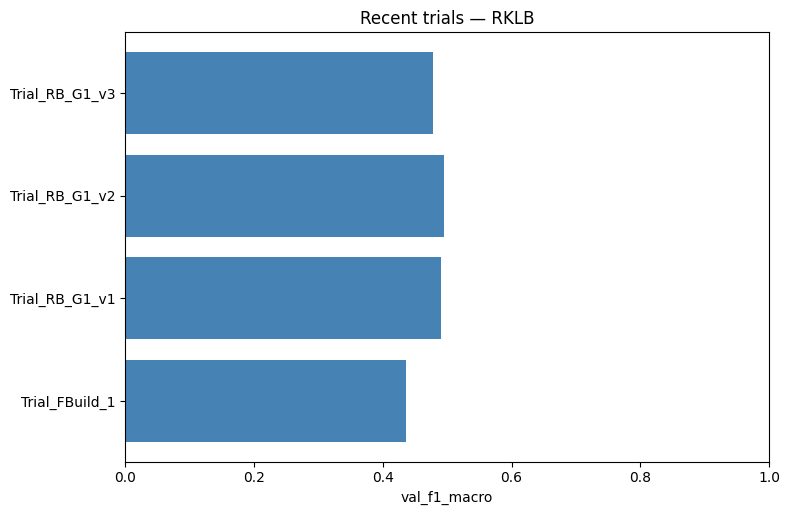

In [47]:
# Chart: prefer val_f1_macro (better for imbalanced labels), fall back to val_accuracy
import matplotlib.pyplot as plt

if log_path.is_file() and len(trials):
    plot_df = trials.copy()
    metric_col = "val_f1_macro" if "val_f1_macro" in plot_df.columns else "val_accuracy"
    plot_df = plot_df.dropna(subset=[metric_col])
    label_col = "train_experiment_name" if "train_experiment_name" in plot_df.columns else "run_id"
    plot_df["label"] = plot_df[label_col].fillna(plot_df["run_id"]).astype(str)
    plot_df = plot_df.sort_values(metric_col, ascending=True).tail(15)

    fig, ax = plt.subplots(figsize=(8, max(3, 0.35 * len(plot_df))))
    ax.barh(plot_df["label"], plot_df[metric_col], color="steelblue")
    ax.set_xlabel(metric_col)
    ax.set_title(f"Recent trials — {cfg.symbol.upper()}")
    ax.set_xlim(0, 1)
    plt.tight_layout()
    plt.show()
else:
    print("Nothing to plot yet.")

In [48]:
# Per-class val metrics for the latest run (or the one you just trained)

def load_latest_metrics(symbol: str, artifacts_dir: str = "artifacts") -> tuple[Path, dict]:
    sym_dir = REPO_ROOT / artifacts_dir / symbol.upper()
    if not sym_dir.is_dir():
        raise FileNotFoundError(sym_dir)
    runs = sorted(p for p in sym_dir.iterdir() if p.is_dir() and (p / "metrics.json").is_file())
    if not runs:
        raise FileNotFoundError("No runs with metrics.json")
    latest = runs[-1]
    return latest, json.loads((latest / "metrics.json").read_text(encoding="utf-8"))

run_dir = last_run_dir if last_run_dir is not None else load_latest_metrics(cfg.symbol)[0]
metrics = json.loads((run_dir / "metrics.json").read_text(encoding="utf-8"))
report = metrics.get("classification_report_val", {})
rows = []
for name, stats in report.items():
    if isinstance(stats, dict) and "f1-score" in stats:
        rows.append({"class": name, **stats})
if rows:
    display(pd.DataFrame(rows).set_index("class")[["precision", "recall", "f1-score", "support"]])
    print("Run:", run_dir.name)
else:
    print("No classification_report_val in metrics.json")

,precision,recall,f1-score,support
class,,,,
stop_loss,0.506619,0.660911,0.573569,637.0
take_profit,1.000000,0.051282,0.097561,78.0
vertical,0.798077,0.728070,0.761468,1368.0
macro avg,0.768232,0.480088,0.477533,2083.0
weighted avg,0.716508,0.682189,0.679146,2083.0


Run: 20260621T045736_776814Z
